In [1]:
import sys
sys.path.append('../')

from config import *
from figs_config import *

Loaded aesthetics module


# Intracranial EEG
This section contains code for visualizing **raw data**, **cross-validation samples**, and for conducting **variography**

In [2]:
# define some colours
import matplotlib.pyplot as plt

cv_colour = plt.cm.Oranges(0.2)
og_colour = plt.cm.Oranges(0.5)
test_colour = plt.cm.cool(1.0)

In [3]:
import joblib
fband = 'alpha'

## Variography of CV samples

### To compare variograms: need to
- map coordinates to the same space

In [4]:
# Bring DSK33 parcel centroid coordinates to MNI space

ctx_dsk33 = joblib.load(projdir + '/data/fsLR-4k_midthickness_parc-dsk33.pkl')
mni_cents = fslr_to_mni_coords_transform(coords = ctx_dsk33[2], inverse=False)

In [5]:
# Bring MEG to MNI space

trg_pvdata = joblib.load(projdir + '/data/fsLR-4k_reduced-midthickness_neuromaps.pkl')
mni_meg = fslr_to_mni_coords_transform(coords = trg_pvdata.points, inverse=False)

In [6]:
# Intracranial EEG channel coordinates are already in MNI space

src_pvdata = joblib.load(projdir + f'/data/icbm09c_left-volume_ieeg-{fband}-pet.pkl')

## Choosing covariates

In [9]:
import run_wrappers

Yk0, yk1 = run_wrappers.generate_covariates(curr_map=f'{fband}_zscored_no_outlier', \
                                        src_polydata=src_pvdata, \
                                        trg_polydata=src_pvdata, \
                                        nspins=3000, datasource='ieeg-alpha-pet')

alpha_zscored_no_outlier
['pet_dukart2018_fpcit' 'pet_radnakrishnan2018_gsk215083'
 'pet_aghourian2017_feobv' 'pet_turtonen2020_carfentanil'
 'pet_hillmer2016_flubatine']
[-0.0946162   0.10580544 -0.10626776 -0.17500425 -0.19685802]


/home/yzhou/anaconda3/envs/py311/lib/python3.11/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [ ]:
* look at data

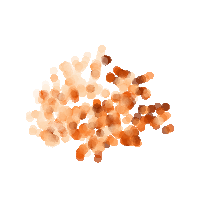

In [10]:
import pyvista as pv

pl = pv.Plotter(window_size = (200,200))

pl.add_points(pv.PolyData(src_pvdata.points).rotate_z(180), scalars = src_pvdata[f'{fband}_zscored_no_outlier'], \
              point_size = 8, cmap = "Oranges", opacity = .7, show_scalar_bar=False, **point_aes)
pl.camera_position = 'yz'
pl.show(jupyter_backend='static')

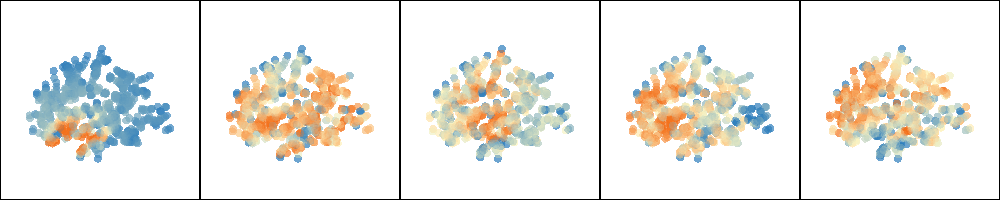

In [11]:
import pyvista as pv

covariates = ['pet_dukart2018_fpcit', 'pet_radnakrishnan2018_gsk215083',
 'pet_aghourian2017_feobv', 'pet_turtonen2020_carfentanil',
 'pet_hillmer2016_flubatine']

pl = pv.Plotter(shape=(1,5), window_size = (1000,200))

for i in range(5):
    pl.subplot(0,i)

    pl.add_points(pv.PolyData(src_pvdata.points).rotate_z(180), scalars = src_pvdata[covariates[i]], point_size = 8, \
                  clim = (np.percentile(src_pvdata[covariates[i]], 5), np.percentile(src_pvdata[covariates[i]], 95)),\
                  cmap = gnrd, opacity = .7, show_scalar_bar=False, **point_aes)
    pl.camera_position = 'yz'
pl.show(jupyter_backend='static')

In [21]:
curr_map = f'{fband}_zscored_no_outlier'
other_maps = src_pvdata.array_names

CMAT = np.ones(len(other_maps))

for j, other_map in enumerate(other_maps):

    CMAT[j] = np.ma.corrcoef(np.ma.masked_invalid(src_pvdata[curr_map]), \
                    np.ma.masked_invalid(src_pvdata[other_map]))[1,0]

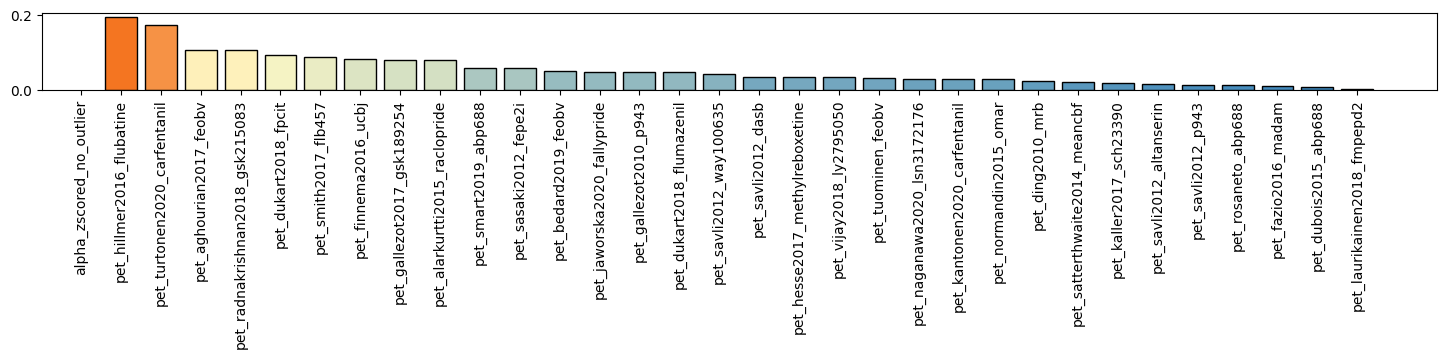

In [22]:
import matplotlib.pyplot as plt
CMAT[0] = np.nan

values = abs(CMAT)


hvals = values[ values.argsort()][::-1]
colors = [ gnrd(value*5) for value in hvals ]

plt.figure(figsize = (18,1))
plt.bar(x=np.array(other_maps)[values.argsort()][::-1], height=hvals, color=colors, edgecolor = 'k')
plt.ylim = ([0.0, 0.20])
plt.xticks(ticks=np.array(other_maps)[values.argsort()][::-1], labels = np.array(other_maps)[values.argsort()][::-1], rotation=90)

plt.show()

# Interpolated maps

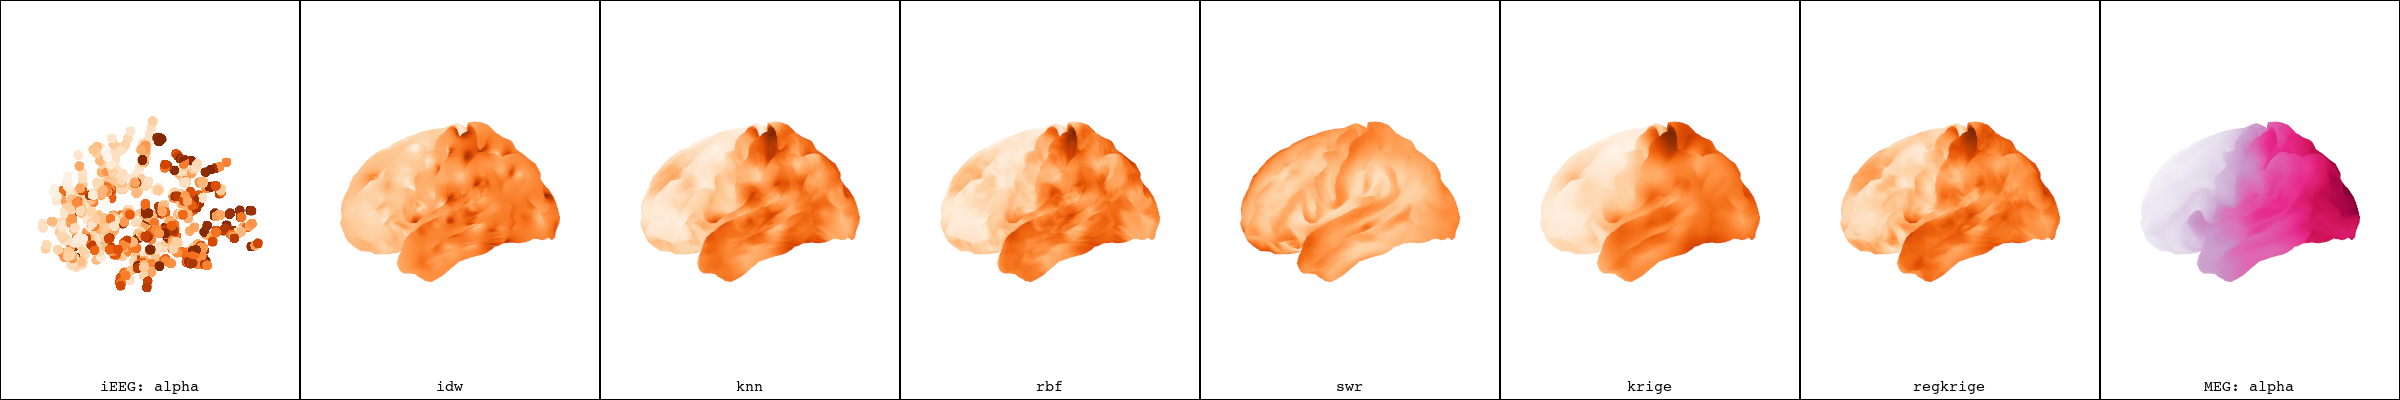

In [127]:
import pyvista as pv

compare_maptag = 'hcps1200_megalpha'

corr = dict.fromkeys(approaches)

space = 'fsLR-4k' # this is the target space
maptag = "alpha_no_outlier"
datasource = "ieeg-alpha-pet"
strategy = 'all'
percentage = 100

reduced_mesh = joblib.load(projdir + '/data/fsLR-4k_reduced-midthickness_neuromaps.pkl')
src_pvdata = joblib.load(projdir + '/data/icbm09c_left-volume_ieeg-alpha-pet.pkl')
results = joblib.load(projdir + f'/results/standard-consensus/ieeg/{space}_{maptag}_volume_{datasource}_samp-{strategy}_pct-{percentage}_0_all_info.pkl')

pl = pv.Plotter(shape = (1,len(approaches) + 2), window_size = (2400, 400))

pl.subplot(0,0)
pl.add_points(src_pvdata.rotate_z(180), scalars = f"alpha_zscored_no_outlier", cmap = "Oranges", \
                      point_size = 10, show_scalar_bar=False, **point_aes)
pl.add_text("iEEG: alpha", position = "lower_edge", font = "courier", font_size = 7)
pl.camera_position = "yz"

pl.subplot(0,7)
pl.add_mesh(reduced_mesh.rotate_z(180), scalars = compare_maptag, cmap = "PuRd", **mesh_aes)
pl.add_text("MEG: alpha", position = "lower_edge", font = "courier", font_size = 7)
pl.camera_position = "yz"

for ai, approach in enumerate(approaches):
    pl.subplot(0,ai + 1)
    if not isinstance(results['interpolated'][approach], np.ndarray): continue
    pl.add_mesh(reduced_mesh.rotate_z(180), scalars = results['interpolated'][approach], cmap = "Oranges", **mesh_aes)
    pl.add_text(approach, position = "lower_edge", font = "courier", font_size = 7)

    corr[approach] = np.corrcoef( results['interpolated'][approach], reduced_mesh[compare_maptag] )[1,0]
    
    pl.camera_position = "yz"

pl.show(jupyter_backend = 'static')

- inspect the distance bins

In [23]:
from interpmodules import helpers

src_EDist = helpers.internal_distance_matrix(src_pvdata.points)

In [24]:
# EVEN BINS IN MNI SPACE !!

nh = 25
bin_edges = np.linspace(0.000001, src_EDist.max(), nh + 1)

In [25]:
import matplotlib.pyplot as plt


median_dist = np.zeros(mni_cents.shape[0])
parcel_dist = np.zeros((mni_cents.shape[0], src_pvdata.points.shape[0]))


for j in range(mni_cents.shape[0]):

    dj = helpers._get_distance_between(mni_cents[j,:].reshape(1,-1), src_pvdata.points)

    median_dist[j] = np.median(dj)
    parcel_dist[j,:] = dj

In [26]:
mdist_order = np.arange(mni_cents.shape[0])[ median_dist.argsort() ]

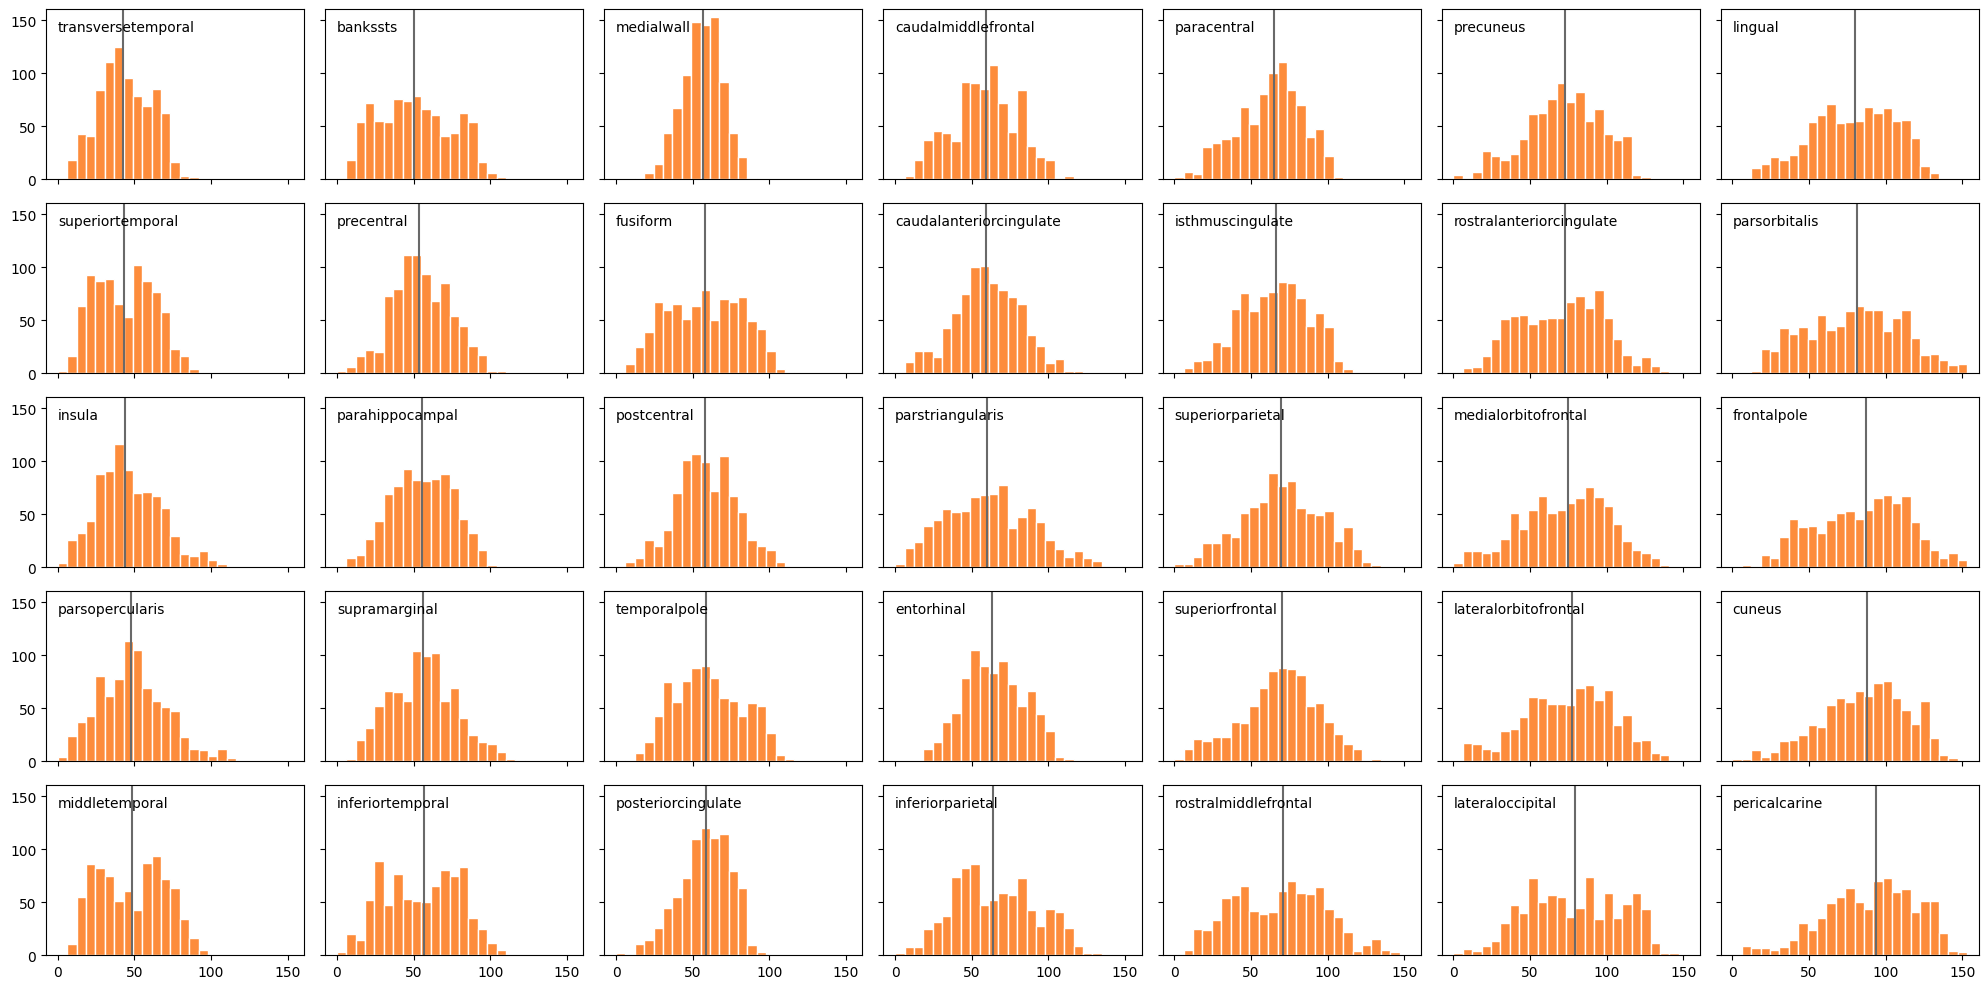

In [27]:
# Plotting the distance bins

fig, axs = plt.subplots(5,7, figsize = (20,10), sharex=True, sharey=True)

for ji, j in enumerate(mdist_order):
    
    row, col = ji % 5, ji // 5

    dj = parcel_dist[j,:]
    
    axs[row, col].hist(dj.flatten(), bins = bin_edges, facecolor=to_hex(og_colour), edgecolor = 'w')
    axs[row, col].axvline(median_dist[j], color = 'dimgray')
    axs[row, col].text(x=0, y=140, s=ctx_dsk33[0][j], color = 'k')

plt.tight_layout()

- load the cross-validation sample point sets

In [28]:
cv_train_coords, cv_train_verts, cv_test_coords, cv_test_verts = [], [], [], []


for ji in range(mni_cents.shape[0]):

    train_coords, train_verts, test_coords, test_verts = helpers.cv_distdep_noreplace(pvdata=src_pvdata, \
                                                                                      center=mni_cents[ji,:], \
                                                                                      nfolds=5, rseed=321)
    cv_train_coords.append(train_coords)
    cv_train_verts.append(train_verts)
    cv_test_coords.append(test_coords)
    cv_test_verts.append(test_verts)

- compute variogram for the whole iEEG map

In [29]:
from scipy.stats import zscore

z_fullsparse = src_pvdata[f'{fband}_zscored_no_outlier']

h, ev, nbin = helpers.get_empirical_variogram_fast(x=z_fullsparse, \
                                                  X=src_pvdata.points, \
                                                  D = src_EDist,\
                                                h_bounds = bin_edges, \
                                                  nh = nh)
z_fullsparse_vgm = (h,ev)

In [30]:
def get_bin_centers(bin_edges):

    return (bin_edges[:-1] + bin_edges[1:]) / 2

In [31]:
import pandas as pd

N = dict.fromkeys(['euclidean', 'geodesic'])

In [33]:
from scipy.sparse import coo_matrix
from scipy.spatial import KDTree

max_lag = np.nanmax(src_EDist)
tree = KDTree(src_pvdata.points)
x = src_pvdata['alpha_zscored_no_outlier']
spdist = tree.sparse_distance_matrix(tree, max_distance=max_lag, output_type='coo_matrix')

i_idx = spdist.row
j_idx = spdist.col
dist_ij = spdist.data

df = pd.DataFrame({
    'h': dist_ij,
})

bin_edges = np.linspace(0.000001, max_lag, nh + 1)
df['bins'] = pd.cut(df['h'], bin_edges)

N['euclidean'] = df.groupby('bins')['h'].count().values

In [34]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap_cont = plt.cm.gist_yarg

colors = cmap_cont(np.linspace(0,1,nh))
cmap_discrete = ListedColormap(colors)

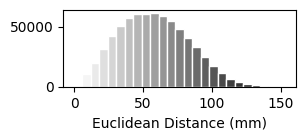

In [36]:
figs, ax = plt.subplots(1,1, figsize = (3,1))

bin_edges = np.linspace(0.000001, np.nanmax(src_EDist), nh + 1)
bincenters = [ ( bin_edges[i] + bin_edges[i + 1] ) / 2 for i in range(nh) ]
binwidth = bincenters[1] - bincenters[0]

ax.bar(x=bincenters, height=N["euclidean"], align = 'center', edgecolor = 'w', color = colors, width=binwidth)
ax.set_xlabel("Euclidean Distance (mm)")

plt.show()

In [37]:
np.where(N['euclidean'] == N['euclidean'].max())

(array([9]),)

In [38]:
print(bin_edges[8], bin_edges[9])

49.00599215043145 55.13174104423538


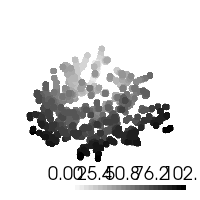

In [40]:
import copy
import pyvista as pv
from matplotlib.colors import ListedColormap
N=25
cmap_cont = plt.cm.gist_yarg

colors = cmap_cont(np.linspace(0,1,N))
cmap_discrete = ListedColormap(colors)

pl = pv.Plotter(window_size = (200,200))

#pl.add_points(sphere_mesh.points[12], color = 'r', point_size = 12,  **point_aes)
pl.subplot(0,0)
pl.add_points(pv.PolyData(src_pvdata).rotate_z(180), scalars=src_EDist[100], opacity=1, cmap = cmap_discrete, point_size = 7, **point_aes)
pl.camera_position = 'yz'

#pl.subplot(0,1)
#pl.add_points(pv.PolyData(src_pvdata).rotate_z(180), scalars=GDist[20], opacity =1, cmap = cmap_discrete, **mesh_aes)
#pl.camera_position = 'yz'

pl.show(jupyter_backend = 'static')

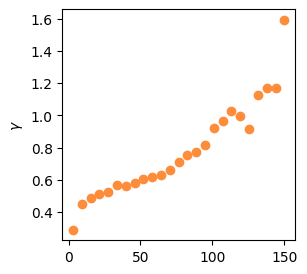

In [41]:
import matplotlib.pyplot as plt

p = plt.figure( figsize = (3,3) )

plt.scatter(z_fullsparse_vgm[0], z_fullsparse_vgm[1], color = og_colour)
plt.ylabel(r"$\gamma$")

plt.show()

- compute variogram for the whole MEG map

In [42]:
fulldense = trg_pvdata[f'hcps1200_meg{fband}']
z_fulldense = zscore(fulldense)

trg_EDist = helpers.internal_distance_matrix(mni_meg)

h, ev, nbin = helpers.get_empirical_variogram_fast(x=z_fulldense, \
                                                  X=mni_meg, \
                                                  D=trg_EDist, \
                                                   h_bounds=bin_edges, \
                                                  nh = nh)

z_fulldense_vgm = (h,ev,nbin)

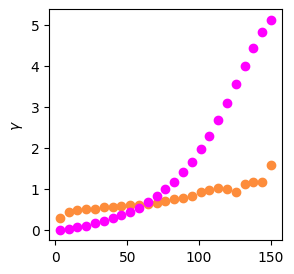

In [18]:
plt.figure(figsize = (3,3))
plt.scatter(z_fullsparse_vgm[0], z_fullsparse_vgm[1], color = og_colour)
plt.scatter(z_fulldense_vgm[0], z_fulldense_vgm[1], color = test_colour)
plt.ylabel(r"$\gamma$")

plt.show()

^^ This is without sill normalization. Not useful information.

In [89]:
nfolds = 5

ev_s = []
expvgm_parcel = []
expvgm_distbin = []
expvgm_parcdist = []

for ji in range(mni_cents.shape[0]):
    for fi in range(nfolds):
        h,ev,nbins = helpers.get_empirical_variogram_fast(x=z_fullsparse[cv_train_verts[ji][fi]], \
                                    X=cv_train_coords[ji][fi], \
                                    D=parcel_dist[ji,:], \
                                    h_bounds = bin_edges, \
                                    nh=nh)
        ev_s.append(ev)
        expvgm_parcel.append(ji)
        expvgm_distbin.append(fi)
        expvgm_parcdist.append(median_dist[ji])

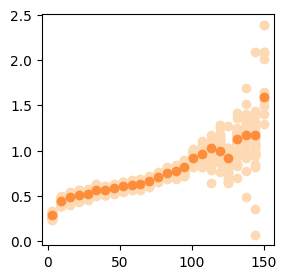

In [44]:
plt.figure(figsize = (3,3))

for si in range(len(ev_s)):
    plt.scatter(h,ev_s[si],color=cv_colour)
plt.scatter(z_fullsparse_vgm[0], z_fullsparse_vgm[1], color = og_colour)
plt.show()

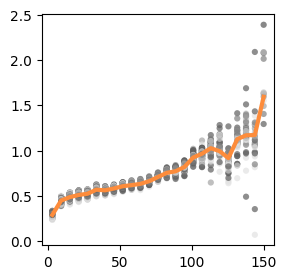

In [53]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

N = 5
cmap = plt.cm.Grays
colors = cmap(np.linspace(0.2, .7, N))
distbinmap = mcolors.ListedColormap(colors)

plt.figure(figsize = (3,3))
for si in range(len(ev_s)):
    plt.scatter(x=get_bin_centers(bin_edges), y=ev_s[si], edgecolor = 'none', s=20, alpha = 0.7, color=distbinmap(expvgm_distbin[si]), rasterized=True)
plt.plot(z_fullsparse_vgm[0], z_fullsparse_vgm[1], color = og_colour, linewidth = 3)
plt.show()

- fit an exponential variogram

In [45]:
import skgstat as skg

binned_vario = skg.Variogram(coordinates = src_pvdata.points, \
             values = z_fullsparse, \
             model = "exponential", \
             n_lags = 25, bin_func = 'even', use_nugget = True)

x, y = binned_vario.get_empirical(bin_center=True) # this gives the same result as my own code

bounds = (0.00001, [np.nanmax(x), np.nanmax(y), np.nanmax(y)/10])
binned_vario.fit(force=True, method = 'trf', p0=bounds[1], maxfev=1000)

theoretical = binned_vario.transform(x)


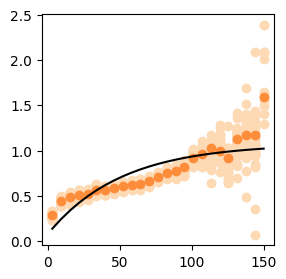

In [54]:
plt.figure(figsize = (3,3))

for si in range(len(ev_s)):
    plt.scatter(h,ev_s[si],color=cv_colour)
    
plt.scatter(h, z_fullsparse_vgm[1],color=og_colour)
plt.plot(h, theoretical, color = 'k')
plt.show()

In [46]:
from interpmodules import metrics

mae_og = np.mean( metrics.metric(theoretical, y , method='residual') )

In [47]:
mae_cv = []

for si in range(len(ev_s)):
    
    mae_cv.append(np.nanmean( metrics.metric(theoretical, ev_s[si], method='residual') ))

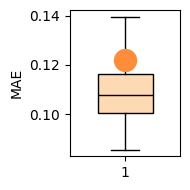

In [48]:
plt.figure(figsize = (2,2))

b = plt.boxplot(mae_cv, widths = 0.5, showfliers=False, patch_artist=True, 
            medianprops=dict(color='k', linewidth=1),\
           whiskerprops=dict(color='k', linewidth=1),\
           capprops=dict(color='k', linewidth=1),\
           boxprops=dict(color='k', linewidth=1)
)

b['boxes'][0].set_facecolor(cv_colour)
plt.scatter(x=1, y=mae_og, color=og_colour, s=250, zorder = 10)
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

In [49]:
p = (np.sum(np.abs(mae_cv - np.mean(mae_cv)) >= np.abs(mae_og - np.mean(mae_cv))) + 1) / (len(mae_cv) + 1)

In [50]:
p

np.float64(0.4090909090909091)

### full plot

In [58]:
joined_vgm = np.vstack(ev_s + [z_fullsparse_vgm[1]] + [theoretical])

In [59]:
# scale the dense one wrt the sparse one
target_sill = np.nanmax(z_fullsparse_vgm[1])  # ≈ 1.2
current_sill = np.nanmax(z_fulldense_vgm[1])

scaled_fulldense_vgm = z_fulldense_vgm[1] * (target_sill / current_sill)

* coverage

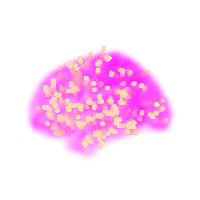

In [64]:
import pyvista as pv

pl = pv.Plotter(window_size = (200,200))

pl.add_points(pv.PolyData(mni_meg).rotate_z(180), opacity = .05, color = test_colour, point_size = 20, style = "points_gaussian")

pl.add_points(pv.PolyData(src_pvdata.points).rotate_z(180), opacity = 1, point_size = 5, color = cv_colour, **point_aes)
pl.camera_position = 'yz'
pl.show(jupyter_backend = 'static')


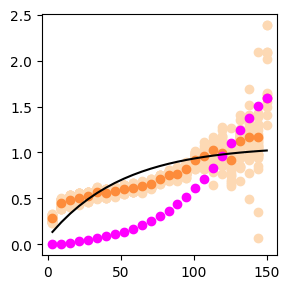

In [62]:
plt.figure( figsize = (3,3) )


for si in range(len(ev_s)):
    plt.scatter(h, joined_vgm[si],color=cv_colour)

plt.scatter(h,z_fullsparse_vgm[1],color=og_colour)
plt.scatter(z_fulldense_vgm[0], scaled_fulldense_vgm,color=test_colour)
plt.plot(h,joined_vgm[-1,:],color='k')

plt.tight_layout()

- fit an exponential model to dense MEG map as well & compare parameters

In [65]:
import skgstat as skg
from scipy.optimize import curve_fit

nparams = 3
h,ev,nbins = z_fulldense_vgm

bounds = ([0.00001]*nparams, [np.nanmax(h), np.nanmax(ev), np.nanmax(ev)/nh])

cof, cov = curve_fit(helpers.exponential, h, ev, method = 'trf', \
                     p0=bounds[1], bounds = bounds, maxfev=1000)
v_pred = helpers.exponential(h, *cof)


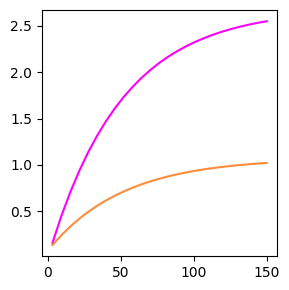

In [66]:
plt.figure(figsize = (3,3))
plt.plot(h,v_pred, color = test_colour)
plt.plot(h,theoretical, color = og_colour)
plt.tight_layout()

In [67]:
r_meg = cof[0]
r_ieeg = binned_vario.parameters[0]
print(r_meg); print(r_ieeg)

150.0808488981963
153.14372334509827


In [68]:
sill_meg = cof[1] + cof[2]
sill_ieeg = binned_vario.parameters[1] + binned_vario.parameters[2]

In [69]:
sill_ratio = sill_meg / sill_ieeg
sill_ratio

np.float64(2.496219436814677)

In [70]:
import numpy as np

ev_test = z_fulldense_vgm[1]
theo_og = theoretical
dense_bins = z_fulldense_vgm[2]

mask = np.isfinite(ev_test) & np.isfinite(theo_og) & (dense_bins > 1000)  # pick threshold
w = dense_bins[mask].astype(float)

diff = ev_test[mask] - theo_og[mask]

wrmse = np.sqrt(np.sum(w * diff**2) / np.sum(w))
wmae  = np.sum(w * np.abs(diff)) / np.sum(w)

print("WRMSE:", wrmse)
print("WMAE :", wmae)

WRMSE: 0.8514371362440586
WMAE : 0.5209870072229292


# Are the different cv splits different from e/o? across parcels
Note: distbin (distance bin) is interchangeable with "cv split" as we make the split based on distance bins

In [90]:
import pandas as pd
expvgm_df = pd.DataFrame(np.vstack(ev_s))
expvgm_df['parcel'] = expvgm_parcel
expvgm_df['parcdist'] = expvgm_parcdist
expvgm_df['distbin'] = expvgm_distbin
expvgm_df['mae_full'] = mae_cv

In [91]:
df_long = expvgm_df.melt(
    id_vars=["parcel", "distbin", "mae_full", "parcdist"],   # columns to keep
    value_vars=list(range(25)),      # columns 0–24
    var_name="h",                    # new column for former column names
    value_name="ev"                  # new column for values
)

In [93]:
import statsmodels.formula.api as smf

df = df_long
df["parcel"] = df["parcel"].astype("category")
df["distbin"] = df["distbin"].astype("category")

model = smf.ols(
    "mae_full ~ parcdist + C(distbin) + C(parcel)",
    data=df
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mae_full   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.479
Method:                 Least Squares   F-statistic:                 4.465e+04
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        11:10:25   Log-Likelihood:                 13160.
No. Observations:                4375   AIC:                        -2.624e+04
Df Residuals:                    4336   BIC:                        -2.599e+04
Df Model:                          38                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0919      0.001    1

In [94]:
pw = model.t_test_pairwise('C(distbin)')

In [95]:
pw.result_frame

,coef,std err,z,P>|z|,Conf. Int. Low,Conf. Int. Upp.,pvalue-hs,reject-hs
1-0,-0.000821,0.000501,-1.636829,1.016662e-01,-0.001804,0.000162,1.016662e-01,False
2-0,-0.004740,0.000529,-8.965913,3.077221e-19,-0.005776,-0.003704,9.231664e-19,True
3-0,-0.006112,0.000586,-10.428963,1.828741e-25,-0.007260,-0.004963,1.097244e-24,True
4-0,0.006621,0.000699,9.475787,2.647566e-21,0.005252,0.007991,1.323783e-20,True
2-1,-0.003919,0.000420,-9.326807,1.091082e-20,-0.004742,-0.003095,4.364330e-20,True
3-1,-0.005291,0.000490,-10.788129,3.916823e-27,-0.006252,-0.004330,2.741776e-26,True
4-1,0.007442,0.000621,11.988385,4.087967e-33,0.006225,0.008659,3.270374e-32,True
3-2,-0.001372,0.000518,-2.647928,8.098680e-03,-0.002388,-0.000357,1.613177e-02,True
4-2,0.011361,0.000643,17.670659,7.056798e-70,0.010101,0.012621,6.351118e-69,True
4-3,0.012733,0.000691,18.429594,7.605213e-76,0.011379,0.014087,7.605213e-75,True


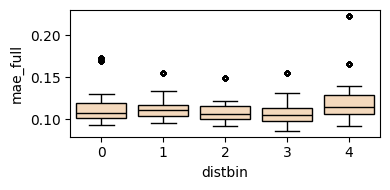

In [96]:
plt.figure(figsize = (4,2))
sns.boxplot(df_long, x='distbin', y='mae_full', fliersize = 3, linecolor = 'k', color = cv_colour)
plt.tight_layout()
plt.show()

## Visualizations alternatively stratified

* values of semivariance for different cv splits

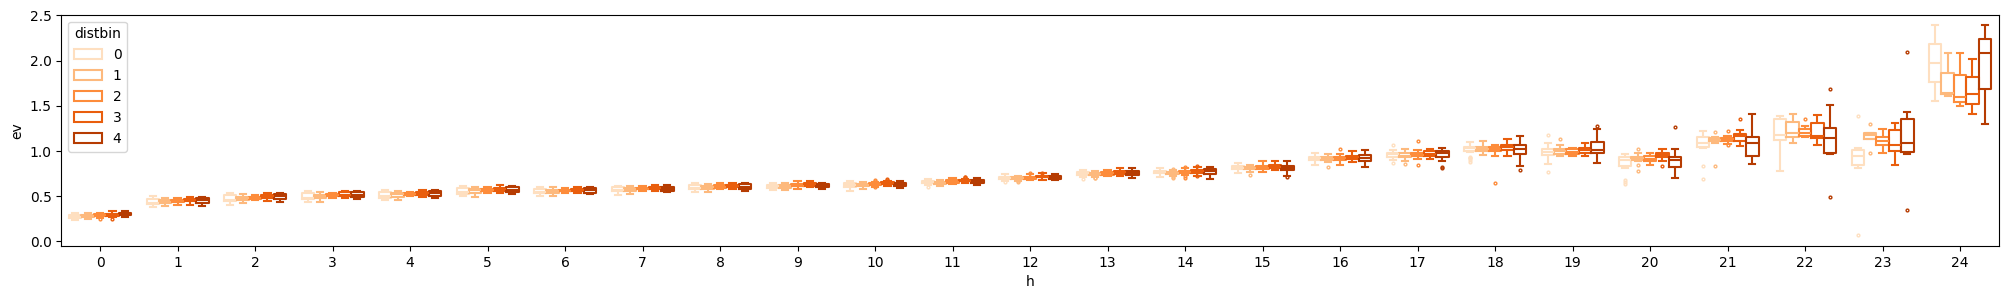

In [97]:
plt.figure(figsize = (25,3))
sns.boxplot(df_long, x='h', y='ev', hue = 'distbin', fliersize=2, palette = 'Oranges', fill =False)
plt.show()

* values of semivariance for different parcel, from distant to far median distance

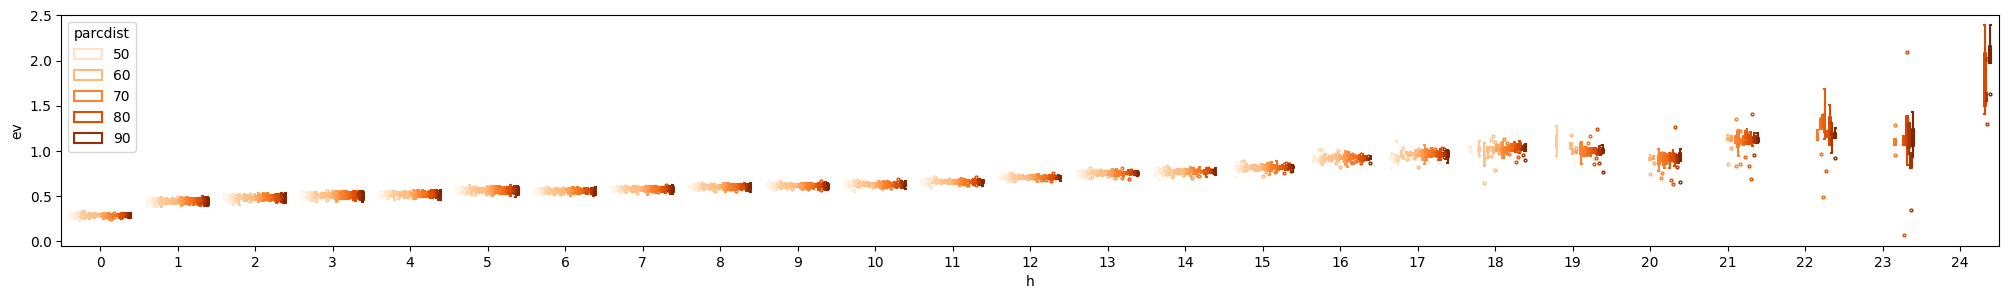

In [98]:
plt.figure(figsize = (25,3))
sns.boxplot(df_long, x='h', y='ev', hue = 'parcdist', fliersize=2, palette = 'Oranges', fill =False)
plt.show()

## CRITERION I: Cross validation ranked performances

In [100]:
import pandas as pd
from interpmodules import metrics
nfolds = 5

dsk33_per_distbin = {}
for lab in np.arange(35):

    cv_parc = joblib.load(projdir + f'/results/distdep_cv/ieeg/use_case_ieeg_{fband}_dsk-parc{lab}_scores.pkl')

    ranks_by_distbin = pd.DataFrame(columns = np.arange(nfolds), index=approaches)

    for db in range(nfolds):
        
        distbin = pd.DataFrame(columns = approaches, index = metrics_to_consider[:-1])
    
        for approach in approaches:
    
            cv_parc[approach].columns = np.arange(5)
            distbin[approach] = cv_parc[approach][db]
            #print(distbin[approach])
    
        run_rank_scores = metrics.accuracy_rank( distbin )
        #print(distbin)
        run_rank_scores = np.mean(run_rank_scores, axis = 1)
        #print(run_rank_scores)
        ranks_by_distbin[db] = run_rank_scores

    dsk33_per_distbin[lab] = ranks_by_distbin

In [101]:
df_long = pd.DataFrame(columns = ['approach', 'rank', 'parcel', 'distbin'])

for lab in np.arange(35):
    out = (
    dsk33_per_distbin[lab]
    .rename_axis("approach")
    .stack()
    .reset_index(name="rank")
    .rename(columns={"level_1": "distbin"})
    )
    out['parcel'] = lab

    df_long = pd.concat([df_long, out])

In [102]:
aorder = df_long.groupby("approach").mean("rank").sort_values("rank", ascending = False).index


In [104]:
results = joblib.load(projdir + f'/results/standard-consensus/ieeg/fsLR-4k_alpha_no_outlier_volume_ieeg-alpha-pet_samp-all_pct-100_0_all_info.pkl')
compare_to_meg = pd.DataFrame(np.vstack([ np.array(results['performance'][1].index), results['performance'][1].to_numpy() ]).T, columns = ['approach', 'rank'])

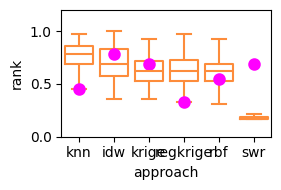

In [111]:
fig, ax = plt.subplots(figsize = (3,2))
sns.boxplot(df_long, x='approach', y='rank',order = aorder, fill=False, fliersize = 0, color=og_colour,legend=False, ax=ax)
sns.pointplot(compare_to_meg, x="approach", y="rank", marker='o', order = aorder, color = test_colour, markersize=7, linestyle='none')
ax.set_ylim(0,1.2)
plt.tight_layout()

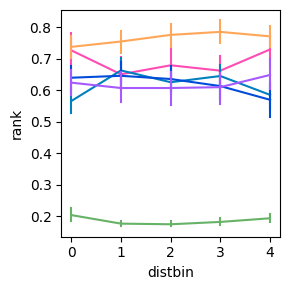

In [112]:
plt.figure(figsize=(3,3))
sns.lineplot(df_long, y='rank', x='distbin', err_style = 'bars', markers = True, hue = 'approach', palette=apal, legend=False)

plt.tight_layout()

In [114]:
import statsmodels.formula.api as smf
df = df_long
df["distbin"] = df["distbin"].astype("category")
df["parcel"] = df["parcel"].astype("category")
df["approach"] = df["approach"].astype("category")

model = smf.ols(
    "rank ~ C(distbin) + C(parcel) + C(approach)",
    data=df
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   rank   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                     191.6
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        11:16:47   Log-Likelihood:                 695.38
No. Observations:                1050   AIC:                            -1303.
Df Residuals:                    1006   BIC:                            -1085.
Df Model:                          43                                         
Covariance Type:                  HC3                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [115]:
df_wide = (
    df_long
    .pivot(index=["parcel", "distbin"], columns="approach", values="rank")
    .reset_index()
)

# optional: remove the column index name ("approach")
df_wide.columns.name = None

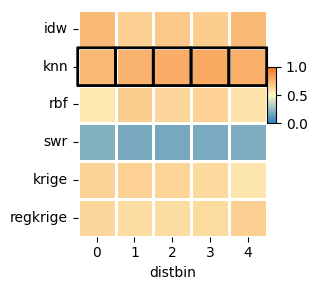

In [116]:
from matplotlib.patches import FancyBboxPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors as mcolors
from matplotlib import cm

data = df_wide.groupby("distbin").mean(approaches).T
data = data.loc[approaches]

fig, ax = plt.subplots(figsize = (8,3))
sns.heatmap( data, cmap = gnrd, vmin = 0, vmax = 1, linewidth=2, linecolor = 'w', square = True, cbar = False, ax=ax)

for distbin in data.columns:
    col_label = distbin
    row_label = data[distbin].sort_values(ascending = False).index[0]

    i = data.index.get_loc(row_label)
    j = data.columns.get_loc(col_label)
    
    #ax.add_patch(
    #    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="dimgray", linewidth=2)
    #)
    
    ax.add_patch(
        FancyBboxPatch(
            (j, i), 1, 1,
            boxstyle="round,pad=0.0001",
            linewidth=2,
            edgecolor="k",
            facecolor="none", clip_on=False
        ))

axins = inset_axes(
    ax,
    width="10%",  # width: 5% of parent_bbox width
    height="50%",  # height: 50%
    loc="lower right",
    bbox_to_anchor=(0.55,0.5, 0.5, 0.5),
    bbox_transform=ax.transAxes,
    borderpad=0,
)

norm = mcolors.Normalize(vmin=0, vmax=1)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=gnrd), cax=axins)

fig.subplots_adjust(right=1.0, bottom = 0.2)

plt.tight_layout()

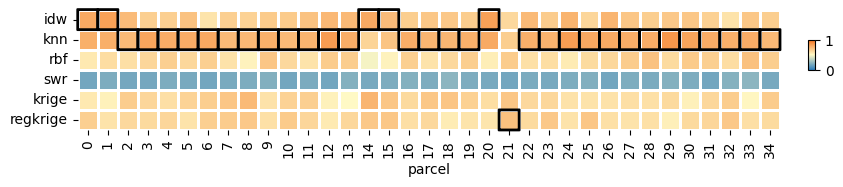

In [117]:
from matplotlib.patches import FancyBboxPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors as mcolors
from matplotlib import cm


fig, ax = plt.subplots(figsize = (8,3))

data = df_wide.groupby("parcel").mean(approaches).T
data = data.loc[approaches]
sns.heatmap( data, cmap = gnrd, vmin = 0, vmax = 1, linewidth = 2, linecolor = 'w', square = True, cbar = False, ax=ax)

for parc in data.columns:
    col_label = parc
    row_label = data[parc].sort_values(ascending = False).index[0]

    i = data.index.get_loc(row_label)
    j = data.columns.get_loc(col_label)
    
    #ax.add_patch(
    #    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="dimgray", linewidth=2)
    #)
    
    ax.add_patch(
        FancyBboxPatch(
            (j, i), 1, 1,
            boxstyle="round,pad=0.0001",
            linewidth=2,
            edgecolor="k",
            facecolor="none", clip_on=False
        ))

axins = inset_axes(
    ax,
    width="2%",  # width: 5% of parent_bbox width
    height="50%",  # height: 50%
    loc="lower right",
    bbox_to_anchor=(0.55,0.5, 0.5, 0.5),
    bbox_transform=ax.transAxes,
    borderpad=0,
)

norm = mcolors.Normalize(vmin=0, vmax=1)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=gnrd), cax=axins)

fig.subplots_adjust(right=1.0, bottom = 0.2)

plt.tight_layout()


## CRITERION II: Comparison with MEG map after Moran nulls

In [118]:
df, nulldistr = joblib.load(projdir + '/results/use_case_ieeg_alpha_nulldistr.pkl')

In [119]:
df = df.sort_values(by = 'r', ascending = False)

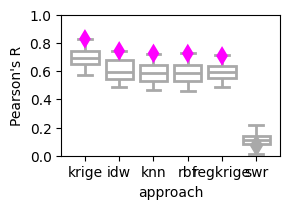

In [122]:
import seaborn as sns

is_significant = df['p'] < .05

fig, ax = plt.subplots(figsize = (3,2))
sns.boxplot(nulldistr, order = df.index, linecolor = 'darkgray', linewidth = 2, color = 'w', ax=ax)
ax.scatter(
    df.index[~is_significant],
    df['r'][~is_significant],
    marker = 'd',
    s=100,
    color='darkgray',
    zorder=5,
    label="Not significant"
)
ax.scatter(
    df.index[is_significant],
    df['r'][is_significant],
    color=test_colour,
    marker = 'd',
    edgecolor = 'none',
    s=100,
    zorder=5,
    linewidth = 2,
    label="Significant"
)
ax.set_ylabel("Pearson's R")
ax.set_ylim(0,1)

plt.tight_layout()
plt.xlabel('approach')

plt.show()